<a href="https://colab.research.google.com/github/charanps24/Aim-Google/blob/main/INFOSYS_ML_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install if needed
!pip install yfinance pandas numpy scikit-learn matplotlib plotly

import yfinance as yf
import pandas as pd

# Download Infosys historical data (NSE ticker)
df = yf.download("INFY.NS", start="2015-01-01", end="2026-04-10")
df.dropna(inplace=True)
df.to_csv("infosys_data.csv")
df.tail()

/tmp/ipykernel_3556/2277501237.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("INFY.NS", start="2015-01-01", end="2026-04-10")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2026-04-02,1300.800049,1305.400024,1259.800049,1260.000000,12873492
2026-04-06,1306.199951,1320.000000,1299.000000,1301.400024,10208682
2026-04-07,1339.400024,1345.099976,1293.500000,1302.000000,15355792
2026-04-08,1346.199951,1376.900024,1331.000000,1349.000000,16030133
2026-04-09,1331.599976,1337.500000,1314.000000,1329.900024,14894607


In [4]:
# Moving averages & technical indicators
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(20).std()

# RSI
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

df.dropna(inplace=True)

In [7]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import pandas as pd # Need to import pandas

# Reload the DataFrame from the CSV to ensure it's not empty
# The original df from the first cell was saved to infosys_data.csv
# Use header=[0, 1] to correctly read the multi-level header
df = pd.read_csv("infosys_data.csv", index_col=0, parse_dates=True, header=[0, 1])

# Flatten the MultiIndex columns to single-level column names
df.columns = df.columns.get_level_values(0)

# Drop 'Adj Close' if it exists, as 'Close' is usually adjusted with auto_adjust=True
if 'Adj Close' in df.columns:
    df = df.drop(columns=['Adj Close'])

# Re-apply feature engineering from the previous cell
# Moving averages & technical indicators
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(20).std()

# RSI
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

# Add a small epsilon to the denominator in RSI calculation to avoid division by zero
# This helps prevent NaN/inf values from propagating if 'loss' is zero.
df['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

# After re-calculating, drop NaNs. This time, with a fresh start from CSV,
# and with epsilon in RSI, it should not empty the DataFrame entirely, but remove initial NaN rows.
df.dropna(inplace=True)

# Check if df is still empty after this step
if df.empty:
    print("Error: DataFrame is empty after reloading and feature engineering. Cannot proceed with model training.")
else:
    # Scale the Close price
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[['Close']]) # Keep df[['Close']] as in original code

    # Create sequences (60 days → predict next day)
    def create_sequences(data, seq_len=60):
        X, y = [], []
        for i in range(seq_len, len(data)):
            X.append(data[i-seq_len:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    # Note: `scaled` is a NumPy array here, so `scaled[:, 0]` is correct.
    X, y = create_sequences(scaled, seq_len=60)

    # Check if sequences were created (X might be empty if df is too small after dropna and seq_len is large)
    if len(X) == 0:
        print(f"Error: Not enough data points ({len(df)} rows) to create sequences of length 60 after dropping NaNs.")
    else:
        X = X.reshape(X.shape[0], X.shape[1], 1)

        # Train-test split (time-ordered — no random shuffle!)
        split = int(len(X) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # LSTM model
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(60, 1)),
            Dropout(0.2),
            LSTM(64),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0158 - val_loss: 9.5313e-04
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0012 - val_loss: 7.5459e-04
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0013 - val_loss: 7.4192e-04
Epoch 8/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0012 - val_loss: 6.9988e-04
Epoch 9/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0013 - val_loss: 6.8991e-04
Epoch 10/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0011 - val_loss: 7.0678e-04
Epoch 11/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 12/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/ste

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step


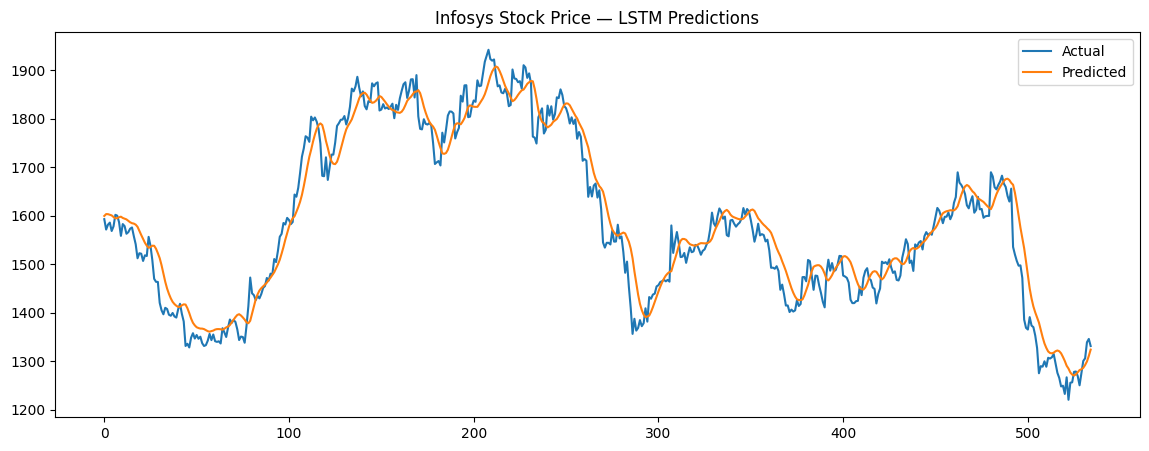

RMSE: ₹42.16


In [8]:
import matplotlib.pyplot as plt

# Predict on test set
preds = scaler.inverse_transform(model.predict(X_test))
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 5))
plt.plot(actual, label='Actual')
plt.plot(preds, label='Predicted')
plt.title('Infosys Stock Price — LSTM Predictions')
plt.legend()
plt.show()

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(actual, preds))
print(f"RMSE: ₹{rmse:.2f}")

In [9]:
# Predict next 30 days
last_60 = scaled[-60:].reshape(1, 60, 1)
future_preds = []

for _ in range(30):
    pred = model.predict(last_60, verbose=0)[0, 0]
    future_preds.append(pred)
    last_60 = np.roll(last_60, -1)
    last_60[0, -1, 0] = pred

future_prices = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))
print(pd.DataFrame(future_prices, columns=['Predicted Close (₹)']))

    Predicted Close (₹)
0           1335.161987
1           1344.201050
2           1352.032349
3           1359.084595
4           1365.636963
5           1371.864502
6           1377.874756
7           1383.733154
8           1389.477783
9           1395.131470
10          1400.708008
11          1406.215454
12          1411.659424
13          1417.042725
14          1422.368774
15          1427.638672
16          1432.853760
17          1438.015137
18          1443.123535
19          1448.179321
20          1453.182373
21          1458.132935
22          1463.030884
23          1467.876099
24          1472.668213
25          1477.406738
26          1482.091675
27          1486.722290
28          1491.298828
29          1495.820435


In [11]:
model.save("infosys_lstm_model.keras")
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [13]:
# app.py
!pip install streamlit
import streamlit as st
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# The previous cell saved the model as .keras, not .h5
model = load_model("infosys_lstm_model.keras")
scaler = joblib.load("scaler.pkl")

st.title("Infosys Stock Price Predictor")
# Upload CSV → predict → show chart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 116.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-04-11 06:36:28.253 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 06:36:28.372 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-11 06:36:28.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 06:36:28.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()